# Health Information Systems and Decision Support Systems
# WPO 5: CAD using deep learning (20/03/2026)
***
*Jakub Ceranka, Pieter Boonen, Panagiotis Gonidakis, Jef Vandemeulebroucke*<br>
*Department of Electronics and Informatics (ETRO)*<br>
*Vrije Universiteit Brussel, Pleinlaan 2, B-1050 Brussels, Belgium*

<font color=blue>Insert students name and IDs here</font>

### Goal
The goal of this practical session is to get an insight into artificial neural networks, more specifically multi-layer perceptrons (MLP) and convolutional neural networks (CNN). Your tasks will involve:
- examining and pre-processing the real life lung nodule CT data
- training various neural networks with increasing complexity to classify if there is a lung nodule on the CT image
- validating the performance of your system against the manual ground-truth predictions prepared by an experienced radiologist.
- visualizing training graphs and analysing information about model performance

Students must send their notebook (and `wandb` generated report for all models in `pdf`) using the Assignment functionaly of Canvas before <b> 26/03/2026, 23:59 pm. </b>, in `.ipynb` and `.html` format. The grade from this practical session will contribute to your final grade.

Questions: Teams group and Breakout Rooms

# Libraries
During this practical session, the following libraries will be used:

* Numpy (np)
* Glob
* Simple ITK (sitk)
* Matplotlib
* Sklearn
* Tensorflow (tf)
* Keras (you can also use pytorch if you are more familiar)
* wandb

To import any external library, you need to import it using the **import** statement followed by the name of the library and the shortcut. You can additionally check for the module version using **version** command.

* If you use your own laptop, you will need to install new modules.

* These expirements are simplified in order to be run without the need of a powerful GPU. However some training tasks may take 30-40 minutes using a CPU. You can accelerate your expirements if you work on [Google colab](https://colab.research.google.com/) framework where a GPU is offered. Then you need to create a GoogleDrive account and upload all the necessary data (scripts + data).
For more information look [here](https://colab.research.google.com/) and [here](https://colab.research.google.com/notebooks/gpu.ipynb).

### Tensorflow and Keras

TensorFlow (https://www.tensorflow.org/) is an end-to-end open-source platform for machine learning. It’s a comprehensive and flexible ecosystem of tools, libraries and other resources that provide workflows with high-level APIs. The framework offers various levels of concepts for you to choose the one you need to build and deploy machine learning models.

Keras (https://keras.io/), on the other hand, is a high-level neural networks library that is running on the top of TensorFlow. Using Keras in deep learning allows for easy and fast prototyping as well as running seamlessly on CPU and GPU. This framework is written in Python code which is easy to debug and allows ease for extensibility. Keras offers simple and consistent high-level APIs and follows best practices to reduce the cognitive load for the users. Both frameworks provide high-level APIs for building and training models with ease. Keras is built in Python which makes it way more user-friendly than TensorFlow.

In this exercise, <b>we recommend to use Keras</b> which allows to create/train/test neural networks with very few lines of understandable code.

Keras requires Tensorflow to be installed. Normally, the new versions of Keras installs it automatically.

To install Keras, open the anaconda prompt and then type:
 ```pip install keras```
    
If not done automatically:
 ```pip install tensorflow``` and after ```pip install keras```

To start using visualization platform Weights-And-Biases go to (https://wandb.ai/) and create an account. Locally do: ```pip install wandb```


Here are some useful resources (installation + documentation):

* https://phoenixnap.com/kb/how-to-install-keras-on-linux <p>
* https://www.tensorflow.org/install <p>
* https://keras.io/getting_started/ <p>
* https://keras.io/api/models/ <p>
* https://keras.io/api/models/sequential/ <p>
* https://docs.wandb.ai/quickstart <p>
    
(*) For the purpose of this exercise, you don't need to use a GPU; tensorflow and keras can be configured to run on a CPU and the most demanding training tasks should not take more than 30 min. On the other hand, [colab](https://colab.research.google.com/) offers GPU development environment and the training tasks can really be accelerated.

(*) Make sure you are using tensorflow 2. It is advised to verify which version it is being used before looking for any documentation as the APIs differ.

# Lung Nodule Analysis
Lung cancer is the leading cause of cancer-related deaths worldwide. Screening high risk individuals for lung cancer with low-dose CT scans is now being implemented in the United States and other countries are expected to follow soon. In CT lung cancer screening, millions of CT scans will have to be analyzed, which is an enormous burden for radiologists. Therefore, there is a lot of interest in development of computer algorithms to optimize cancer screening.

<img src="images/luna16_image.png">

A vital first step in the analysis of lung cancer CT scans is the detection of pulmonary nodules, which may or may not represent early stage lung cancer. Many computer-aided detection (CAD) systems have already been proposed for this task.

The LIDC/IDRI data set is publicly available, including the ground-truth annotations of nodules performed by four radiologists.

This practical session is inspired from the challenge [LUNA16](https://luna16.grand-challenge.org/home/), which focused on a large-scale evaluation of automatic nodule detection algorithms on the LIDC/IDRI data set.

<img src="images/lung_cancer1.png">


### Using LIDC/IDRI data set in this practical session

For the needs of this practical session, we will look for an algorithm that only determines the likelihood for a given location in a CT scan to contain a pulmonary nodule. Furthermore, we have included a very small part of the LIDC/IDRI data set and we will use only a slice of suspicious regions of a CT scan.

### Data augmentation

Originally our dataset was very unbalanced. There were a lot samples of non-nodules (negatives) but very few samples of nodules (positives). Machine learning algorithms and specifically neural networks and convolutional neural networks require to be trained on balanced dataset, meaning all the classes should be equally represented in the training set.

Using data augmentation methods (**rotation and translation**), positive samples were massively augmented in order to balance the two classes (nodules and non-nodules)

### Ground Truth data

Categorical data are variables that contain label values rather than numeric values. In our dataset, a sample can represent a nodule or a non-nodule area, so initially we have our ground truth data in a categorical form. Many machine learning algorithms cannot operate on label data directly. They require all input variables to be numeric. This means that categorical data must be converted to a numerical form. This involves two steps:
1. Integer Encoding
2. One-Hot Encoding.

As a first step, each unique category value is assigned an integer value. That's why in our dataset, a sample which represents a nodule will have as a label `1` and a sample which represents a non-nodule area will have as a label `0`.

For our case, this enconding step would be enough since we have only two categories. However, in a more general problem with more than two classes, using this encoding allows the model to assume a natural ordering between categories which may result in poor performance or unexpected results. That's why, one hot encoding can be appled to the integer representation. This is where the integer encoded variable is removed and a new binary variable is added for each unique integer value.

Therefore, a  nodule will be represented by the binary variable `[1,0]` and a non-nodule area by the binary variable `[0,1]`.

<img src="images/lung_cancer2.png">


# Part 1: Visualize, load and prepare data for Machine Learning Algorithms

CT images are stored in MetaImage (`mhd/raw`) format. Each .mhd file is stored with as a header file (`.mhd`) and a corresponding pixeldata file (`.raw`). To load a CT image, just **load the `.mhd` header file** and data from the binary .raw file will be automatically loaded.

If you look carefully at the name of each .mhd file, you can extract useful information for a specific sample. You can identify its **number id**, its **size**, if the image was produced by a **data augmentation** method and if it contains a **nodule or not**.

For example: *20046_x0y0z0_20x20x6_r0_1.mhd*
* **20046**:   number of candidate patch
* **x0y0z0**: no translation in any axis (if augmentation is used it is mentioned by the angle in the corresponding axis)
* **20x20x6**: size of the image in voxels
* **r0**:     no rotation
* **1**:      it is a positive sample - represents a nodule
* **.mhd**:   it is a mhd file (this is the file which can be loaded)

### Task 1: Import necessary libraries

Load all necessary libraries using the **import** statement and check for errors.

In [6]:
!pip install SimpleITK

In [7]:
import numpy as np
import glob
import SimpleITK as sitk
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from tensorflow import keras
import wandb

### Task 2: Inspect the dataset

1. Using `SimpleITK`, create a function to load `.mhd` files (__Tip:__ The function should return a numpy array - `sitk.GetArrayFromImage( )`)
2. Visualize the 6 slices of a chosen patch using `matplotlib` subplot figure and mention if it is a positive or a negative patch (Use colorscale `gray`)
3. Visualize some augmented samples from the same candidate region using `matplotlib` subplot of the same patch and mention the augmentation method. Check visually if the observed patch was modified using the same augmentation method that is mentioned in the samples' filename.
4. Count your files. How many positives and negatives there are in this dataset? (__Tip:__ Use `glob` library to get the number of specific files in your dataset).

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
def load_mhd(file_path):
    image = sitk.ReadImage(file_path)
    array = sitk.GetArrayFromImage(image)
    return array

def get_file_info(file_name):
    name = os.path.basename(file_name).replace(".mhd", "")
    parts = name.split("_")

    sample_id = parts[0]
    translation = parts[1]
    size = parts[2]
    rotation = parts[3]
    label = parts[4]

    return {
        "id": sample_id,
        "translation": translation,
        "size": size,
        "rotation": rotation,
        "label": int(label)
    }

In [10]:
import matplotlib.pyplot as plt
import os

def show_patch(file_path):

    patch = load_mhd(file_path)

    info = get_file_info(file_path)
    label = info["label"]

    if label == 1:
        print("Positive patch (nodule)")
    else:
        print("Negative patch (no nodule)")

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))

    for i in range(6):
        axes[i].imshow(patch[i], cmap="gray")
        axes[i].set_title(f"Slice {i+1}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

Negative patch (no nodule)


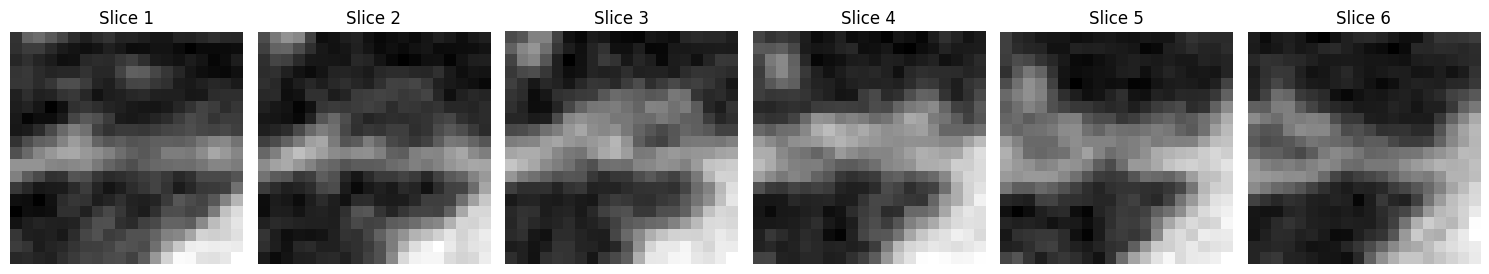

In [11]:
data_path='/content/drive/MyDrive/wpo_5'
file_name = "18998_x0y0z0_20x20x6_r0_0.mhd"
file_path = os.path.join(data_path,"MiniLunaDataset3", "MiniLunaDataset3", file_name)
show_patch(file_path)

20046_x-1y0z0_20x20x6_f0_1.mhd -> Translation: x-1y0z0, Rotation: f0
20046_x-1y0z0_20x20x6_f180_1.mhd -> Translation: x-1y0z0, Rotation: f180
20046_x-1y0z0_20x20x6_f270_1.mhd -> Translation: x-1y0z0, Rotation: f270
20046_x-1y0z0_20x20x6_f90_1.mhd -> Translation: x-1y0z0, Rotation: f90


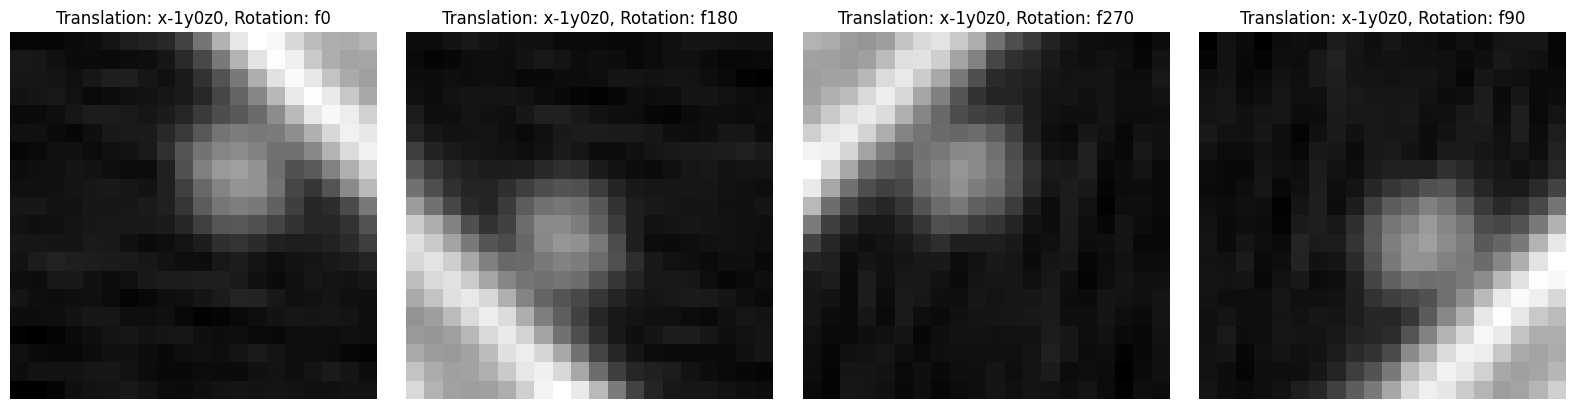

Check visually:
- x...y...z... means the patch should look shifted
- r... means the patch should look rotated
- x0y0z0 and r0 means no augmentation


In [12]:
folder = "/content/drive/MyDrive/wpo_5/MiniLunaDataset3/MiniLunaDataset3"

def load_mhd(file_path):
    image = sitk.ReadImage(file_path)
    return sitk.GetArrayFromImage(image)

def augmentation_method(file_path):
    name = os.path.basename(file_path).replace(".mhd", "")
    parts = name.split("_")
    translation = parts[1]
    rotation = parts[3]

    if translation == "x0y0z0" and rotation == "r0":
        return "No augmentation"
    elif translation != "x0y0z0" and rotation == "r0":
        return f"Translation: {translation}"
    elif translation == "x0y0z0" and rotation != "r0":
        return f"Rotation: {rotation}"
    else:
        return f"Translation: {translation}, Rotation: {rotation}"

candidate_id = "20046"   # change this to any candidate ID you want
files = sorted(glob.glob(os.path.join(folder, f"{candidate_id}_*.mhd")))[:4]

fig, axes = plt.subplots(1, len(files), figsize=(4 * len(files), 4))

if len(files) == 1:
    axes = [axes]

for i, file_path in enumerate(files):
    patch = load_mhd(file_path)
    method = augmentation_method(file_path)

    axes[i].imshow(patch[2], cmap="gray")   # showing one slice from each patch
    axes[i].set_title(method)
    axes[i].axis("off")

    print(os.path.basename(file_path), "->", method)

plt.tight_layout()
plt.show()

print("Check visually:")
print("- x...y...z... means the patch should look shifted")
print("- r... means the patch should look rotated")
print("- x0y0z0 and r0 means no augmentation")

In [13]:
import glob
import os

folder = "/content/drive/MyDrive/wpo_5/MiniLunaDataset3/MiniLunaDataset3"

all_files = glob.glob(os.path.join(folder, "*.mhd"))
positive_files = glob.glob(os.path.join(folder, "*_1.mhd"))
negative_files = glob.glob(os.path.join(folder, "*_0.mhd"))

print("Total files:", len(all_files))
print("Positive files:", len(positive_files))
print("Negative files:", len(negative_files))

Total files: 2315
Positive files: 1101
Negative files: 1214


### Task 3: Data pre-processing
In order to use neural-networks, we need to pre-process the data and store it in a way which can be easily interpreted by keras.

First of all, separate the test set from the train set. Keep 10% of your samples as a test-set. (**Tip:** Use `sklearn` `train_test_split` function.)

Since 3D CNNs need a lot of computation power, we will convert our problem to 2D. Instead of using all the 6 CT slices, we will use only the 3rd CT slice. Therefore, from each sample, the 3rd slice wiil be extracted and further preprocessed. In addition, our values currently range from -1024 HU to around 2000 HU. Anything above 400 is not interesting to us, as these are simply bones with different radiodensity. A commonly used set of thresholds to normalize between is -1000 and 400. Finally the labels will be properly encoded to be used for training and testing.

Write your pre-processing tasks as python functions (listed below) and in the end create a pipeline for each sample which will be also implemented as a function.
1. Function loading the `.mhd` image as a numpy array.
2. Function extracting the 3rd slice of a patch. The final form of patches should be a numpy array of size **20x20** pixels.
3. Function normalizing the dataset.
The unit of measurement in CT scans is the **Hounsfield Unit (HU)**, which is a measure of radiodensity. CT scanners are carefully calibrated to accurately measure this. From Wikipedia:
<img src="images/HU_CTscannersCalibration.png">

    Create a function which is going to normalize the samples according to this table
        * Create numpy arrays
        * Normalize between [-1000, 400] using this normalization method
    $npzarray = (npzarray - minHU) / (maxHU - minHU)$ <br>
         where minHU = -1000 and maxHU = 400
        * After this normalization set any values bigger than 1 to 1 and any values smaller than 0 to 0.

4. Write an `If statement` encoding a label into a **1-hot** label as a ground-truth data in order to train the neural networks. (One-hot labels: `[0,1]` --> negative, `[1,0]` --> positive)

5. Store into `.npy` data binary files. (__Tip:__ Use `np.save` to store data.)

The pipeline should execute the functions as follows: <br>

- Use `train_test_split` to divide the dataset into train and test subsets. Do that on patient level!
- Create empty `np.arrays` filled with zeros to store patches and label data
- Use for loop to iterate over all images in a train set:
    - Load `.mhd` using `sitk`
    - Normalize
    - Extract 3rd slice
    - Extract label as one-hot.
    - Insert into empty array at correct index location
- Save dataset.
- Repeat for a test set.

and return:
* data:  [sample_idx,20,20]
* labels: [sample_idx,2]

Data pre-processing should be done for both: train and test set.

In [14]:
def load_mhd(file_path):
    image = sitk.ReadImage(file_path)
    return sitk.GetArrayFromImage(image)

In [15]:
def get_third_slice(file_path):
    patch = load_mhd(file_path)
    return patch[2]

In [16]:
def normalize_hu(npzarray):
    minHU = -1000
    maxHU = 400

    npzarray = np.array(npzarray, dtype=np.float32)
    npzarray = (npzarray - minHU) / (maxHU - minHU)
    npzarray[npzarray > 1] = 1
    npzarray[npzarray < 0] = 0

    return npzarray

In [17]:
def one_hot_label(label):
    if label == 0:
        return [0, 1]
    else:
        return [1, 0]

In [18]:
def save_npy(file_name, data):
    np.save(file_name, data)

In [19]:
from sklearn.model_selection import train_test_split

all_files = glob.glob(os.path.join(folder, "*.mhd"))

train_files, test_files = train_test_split(
    all_files,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print("Total samples:", len(all_files))
print("Train samples:", len(train_files))
print("Test samples:", len(test_files))

Total samples: 2315
Train samples: 2083
Test samples: 232


In [20]:
X_train = np.zeros((len(train_files), 20, 20), dtype=np.float32)
X_test = np.zeros((len(test_files), 20, 20), dtype=np.float32)

y_train = np.zeros((len(train_files), 2), dtype=np.int32)
y_test = np.zeros((len(test_files), 2), dtype=np.int32)

In [ ]:
for i, file_path in enumerate(train_files):
    patch = load_mhd(file_path)
    patch = normalize_hu(patch)
    patch = patch[2]

    label = int(os.path.basename(file_path).replace(".mhd", "").split("_")[-1])
    if label == 0:
        one_hot = [0, 1]
    else:
        one_hot = [1, 0]

    X_train[i] = patch
    y_train[i] = one_hot

In [22]:
train_files = train_files[:int(len(train_files) * 0.1)]

sample_patch = load_mhd(train_files[0])
sample_patch = normalize_hu(sample_patch)
sample_patch = sample_patch[2]
patch_size = sample_patch.shape[0]

X_train = np.zeros((len(train_files), patch_size, patch_size), dtype=np.float32)
y_train = np.zeros((len(train_files), 2), dtype=np.int32)

for i, file_path in enumerate(train_files):
    patch = load_mhd(file_path)
    patch = normalize_hu(patch)
    patch = patch[2]

    label = int(os.path.basename(file_path).replace(".mhd", "").split("_")[-1])
    if label == 0:
        one_hot = [0, 1]
    else:
        one_hot = [1, 0]

    X_train[i] = patch
    y_train[i] = one_hot

In [ ]:
for i, file_path in enumerate(test_files):
    patch = load_mhd(file_path)
    patch = normalize_hu(patch)
    patch = patch[2]

    label = int(os.path.basename(file_path).replace(".mhd", "").split("_")[-1])
    if label == 0:
        one_hot = [0, 1]
    else:
        one_hot = [1, 0]

    X_test[i] = patch
    y_test[i] = one_hot

In [23]:
test_files = test_files[:int(len(test_files) * 0.1)]

sample_patch = load_mhd(test_files[0])
sample_patch = normalize_hu(sample_patch)
sample_patch = sample_patch[2]
patch_size = sample_patch.shape[0]

X_test = np.zeros((len(test_files), patch_size, patch_size), dtype=np.float32)
y_test = np.zeros((len(test_files), 2), dtype=np.int32)

for i, file_path in enumerate(test_files):
    patch = load_mhd(file_path)
    patch = normalize_hu(patch)
    patch = patch[2]

    label = int(os.path.basename(file_path).replace(".mhd", "").split("_")[-1])
    if label == 0:
        one_hot = [0, 1]
    else:
        one_hot = [1, 0]

    X_test[i] = patch
    y_test[i] = one_hot

In [24]:
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

In case you are not able to complete Part 1, you can move to Part 2 of the session by loading the provided `.npy` files. In that case you will **not** get any credits for Part 1.

# Part 2: Model training and validation

### Using Keras - A High Level API for Tensorflow

Keras introduces a High-Level API that makes neural network building and training fast and easy. This API is intuitive and fully compatible with Tensorflow. In addition, keras provides a plethora of [APIs](https://keras.io/api/models/) and the user may select one that meets his needs. For the purpose of this exercise, the [sequential model](https://keras.io/api/models/sequential/) can be employed.

### Visualization of training curves with `wandb`

For the purpose of visualization in real-time the performance of our training, you will use Weights-And-Biases (`wandb`). During or after training you can use  it  to visualize the network and its performance. <b> For  all the following training tasks you are requested to include the loss and the accuracy graphs for training and also for evaluating the test-set</b>. A simple way to attach these graphs to jupyter notebook is to use generate a report after the training of all your networks is finished. Please upload that report in the pdf format and upload it in yur submission together with this notebook.

Have a look at the following links for some tutorials on first use and report generation in `wandb`:
* https://docs.wandb.ai/quickstart
* https://docs.wandb.ai/guides/reports/create-a-report

### Some Tips:

* Use ```np.load``` to load your data from the previously created .npy binary files.
* Use ```reshape``` method when it is needed to import data to the network.
* Make your own function to create the model for each network architecture to avoid any model conflicts.

* If you trained a model in a past python session, you can load the trained model but first you have to <b>define and initialize it again</b>.

* Use `wandb` to visualize network and performance:

* If you have strange keras errors, restart the python kernel and <b> re-run only the cells concerning your task you currently work (i.e. run the cells concerning only the current keras). Sometimes you cannot load two different keras at the same python session.</b>.

(*) Depending the version of tensorflow you are working some commands might differ. Please look online for recent documentation.

### Task 1: Load Data from the numpy binary files (from Part 1)
Use the `numpy` load function to load the data created in the previous part of the exercise. The data has to be reshaped in a specific way (use code below) in order to be compatible with the keras neural network input standard. After the data is successfully loaded, plot any patch and its ground-truth as image title to verify that data is correctly represented.

In [25]:
# Code for Part 2: Task 1

X = train_data.reshape(-1,IMG_SIZE,IMG_SIZE,1)
X_val = test_data.reshape(-1,IMG_SIZE,IMG_SIZE,1)

NameError: name 'train_data' is not defined

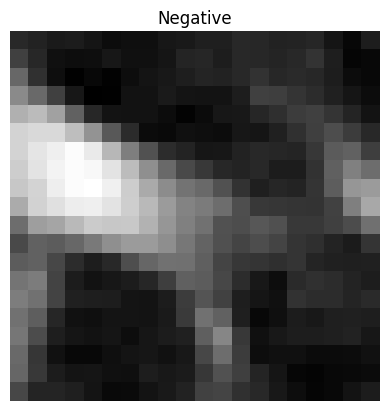

In [26]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

X_train = X_train.reshape(X_train.shape[0], 20, 20, 1)
X_test = X_test.reshape(X_test.shape[0], 20, 20, 1)

i = 0

if (y_train[i] == [1, 0]).all():
    title = "Positive"
else:
    title = "Negative"

plt.imshow(X_train[i].reshape(20, 20), cmap="gray")
plt.title(title)
plt.axis("off")
plt.show()

### Task 2: Artificial Neural Networks (1 layer)
First, lets train our classifier using an artificial neural network with just one layer (perceptron), a fully connected one (dense). This layer will have `softmax` as activation function and only two neurons.

The main advantage of using this activation function is the output range. The range of the outputs will be `[0,1]` and the sum of all the probabilities will be equal to one. Generally, if the softmax function is used for a  multi-classification model it returns the probabilities of each class and the target class will have higher probability.

Using Keras, define your model. Use these hyperparameters:
* Learning Rate = `1e-4`
* Batch Size = `8`
* Optimizer = `sgd`
* Loss metric = `categorical_crossentropy`
* Validation metric score in Keras = `accuracy`

Check your model architecture with `summary()` function.

Since the network is small, it is not recommended to use `Dropout`. Train first for 1-2 epochs to verify that everything works and then train for ~10 epochs. To automatically integrate `wandb` in your Keras `model.fit` function, import `from wandb.keras import WandbMetricsLogger` and add a callback statement: `callbacks=[WandbMetricsLogger()]`. Observe the training and evaluate graphs from `wandb` to decide when to stop training.

To evaluate the trained model, test it with the test samples (use `validation_data` in `model.fit` function).

### Tip:
* Use `.Flatten()` layer first to create a 1D vector in your input layer.
* It is highly recommended to write all the tasks in functions and have as an input argument your keras. Then you will be able to re-use them in the next tasks for different keras.

In [28]:
#from wandb.keras import WandbMetricsLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

In [32]:

y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

model = Sequential()
model.add(Flatten(input_shape=X_train.shape[1:]))
model.add(Dense(2, activation="softmax"))

model.compile(optimizer=SGD(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

wandb.init(project="task2_ann_1layer")

model.summary()

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[WandbMetricsLogger()]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_loss)
print(test_accuracy)

wandb.finish()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           802 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802 (3.13 KB)

 Trainable params: 802 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

NameError: name 'WandbMetricsLogger' is not defined

### Task 3: Test the model
In this section you are going to write a <b>generic</b> validation function to assess the performance of out trained models. To do so, we will need the following modules from `sklearn`:
- `confusion_matrix`
- `accuracy_score`
- `roc_curve`

Import the modules and create a `python` function which takes two input arguments (validation test data and its GT labels). Use `model.predict` method to predict the class of our test set. Using the function print the `confusion_matrix`, `accuracy_score` and a `roc_curve` of this specific model.

Use to function to assess the performance of your first train model. Print all of the validation metrics and a ROC curve.

__Hint__: For the calculation of `confusion_matrix` and `accuracy_score` you need to transform your predicted and GT labels using `np.argmax`.

__Hint__: For the calculation of `roc_curve` take only the second column of the predicted one-hot label e.g. `test_preds = test_preds[:,1]`

Explain these graphs and the ROC curve. What role does the decision threshold play and why it is so important? Can we have a single value as the decision threshold? Why?

In [ ]:
# Answer to the question

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[[7 4]
 [8 4]]
0.4782608695652174


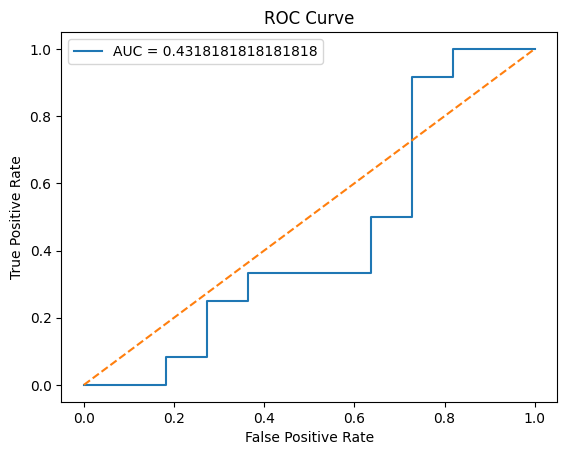

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

def validate_model(model, X_test, y_test):
    test_preds = model.predict(X_test)

    y_pred = np.argmax(test_preds, axis=1).astype(int)

    y_test = np.array(y_test)
    if y_test.ndim == 2:
        y_true = np.argmax(y_test, axis=1).astype(int)
    else:
        y_true = y_test.reshape(-1).astype(int)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]
    test_scores = test_preds[:n, 1]

    print(confusion_matrix(y_true, y_pred))
    print(accuracy_score(y_true, y_pred))

    fpr, tpr, thresholds = roc_curve(y_true, test_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

validate_model(model, X_test, y_test)

### Task 4.1: Artificial Neural Networks (3 layers) - Let's go deep!

From now on, we will try various networks with increasing complexity. Make sure with every network/parameter change, you update any hyperameters; you test and evaluate the new model with the previously used evaluation metrics (ROC curve, confusion matrix...). Moreover, every time check the training curves in `wandb`.

Let's try 3 fully-connected layers using `sigmoid` activation function.

Here is an example network but you are free to choose your own network.
* 1st dense layer with 80 neurons, `sigmoid` activation
* 2nd dense layer with 40 neurons, `sigmoid` activation
* 3rd dense layer with 2 neurons and `softmax` activation
* optimizer: `sgd`
* learning rate: `1e-4`

Explain your network's architecture and **test** your system as you did for the previous simple neural network. What do you observe? Make sure you tune again any hyperparameters like the amount of training epochs. Choose different values for the learning rate, number of epochs and batch size (e.g. 10, 20, 30...). Can you find some training curves which indicate **underfitting** and **overfitting**? If so, what network parameters play a crucial role in observing **underfitting** or **overfitting**?

**Remark:** Some deeper models require more training to reach their optimal performance. If possible with your computational resources, try to train them for more epochs until no increase in accuracy is observed.

In [ ]:
# Answer to the question

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 80)             │        32,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │            82 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,402 (138.29 KB)

 Trainable params: 35,402 (138.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 790ms/step - accuracy: 0.4500 - loss: 1.0175 - val_accuracy: 0.3913 - val_loss: 1.1100
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4500 - loss: 1.0168 - val_accuracy: 0.3913 - val_loss: 1.1092
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4500 - loss: 1.0160 - val_accuracy: 0.3913 - val_loss: 1.1084
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4500 - loss: 1.0153 - val_accuracy: 0.3913 - val_loss: 1.1075
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4500 - loss: 1.0146 - val_accuracy: 0.3913 - val_loss: 1.1067
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4500 - loss: 1.0138 - val_accuracy: 0.3913 - val_loss: 1.1058
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4500 - loss: 1.0131 - val_accuracy: 0.3913 - val_loss: 1.1050
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4500 - loss: 1.0124 - val_accuracy: 0.3913 - val_loss: 1.1041

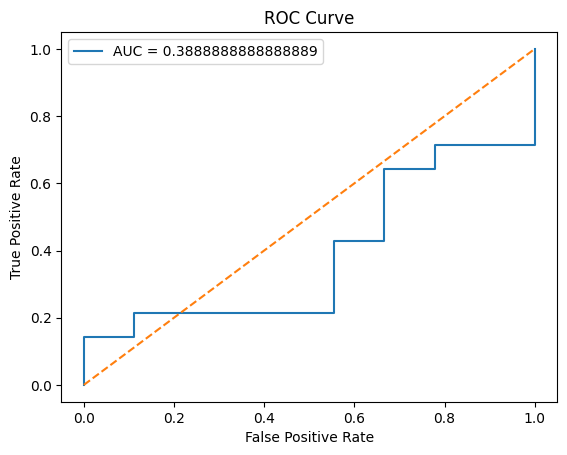

In [44]:
if y_train.ndim > 2:
    y_train = y_train.reshape(y_train.shape[0], -1)
if y_test.ndim > 2:
    y_test = y_test.reshape(y_test.shape[0], -1)

if y_train.shape[1] != 2:
    y_train = np.argmax(y_train, axis=1)
    y_train = to_categorical(y_train, 2)
if y_test.shape[1] != 2:
    y_test = np.argmax(y_test, axis=1)
    y_test = to_categorical(y_test, 2)

model = Sequential()
model.add(Flatten(input_shape=X_train.shape[1:]))
model.add(Dense(80, activation="sigmoid"))
model.add(Dense(40, activation="sigmoid"))
model.add(Dense(2, activation="softmax"))

model.compile(optimizer=SGD(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

wandb.init(project="task4_ann_3layers")

model.summary()

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=10,
    validation_data=(X_test, y_test),
    callbacks=[WandbMetricsLogger()]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(test_loss)
print(test_accuracy)

test_preds = model.predict(X_test)
y_pred = np.argmax(test_preds, axis=1)
y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred))
print(accuracy_score(y_true, y_pred))

fpr, tpr, thresholds = roc_curve(y_true, test_preds[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

wandb.finish()

### Task 4.2: Relu!
RELU = Rectified Linear Unit

Let's try the same network but using RELU instead of sigmoid now.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 80)             │        32,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │            82 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,402 (138.29 KB)

 Trainable params: 35,402 (138.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 810ms/step - accuracy: 0.5000 - loss: 0.7033 - val_accuracy: 0.5652 - val_loss: 0.6736
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 0.7030 - val_accuracy: 0.5652 - val_loss: 0.6735
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5000 - loss: 0.7028 - val_accuracy: 0.5652 - val_loss: 0.6734
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5000 - loss: 0.7024 - val_accuracy: 0.5652 - val_loss: 0.6733
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 0.7022 - val_accuracy: 0.5652 - val_loss: 0.6732
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5000 - loss: 0.7019 - val_accuracy: 0.5652 - val_loss: 0.6731
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5000 - loss: 0.7016 - val_accuracy: 0.5652 - val_loss: 0.6730
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5000 - loss: 0.7013 - val_accuracy: 0.5652 - val_loss: 0.6729

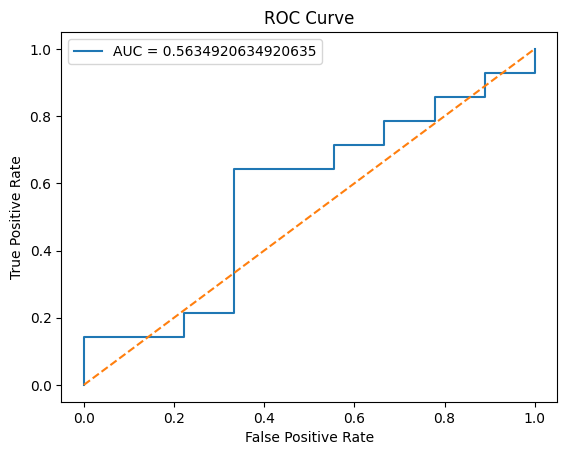

In [45]:
# Code for Part 2: Task 4.2
model = Sequential()
model.add(Flatten(input_shape=X_train.shape[1:]))
model.add(Dense(80, activation="relu"))
model.add(Dense(40, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.compile(optimizer=SGD(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

wandb.init(project="task4_ann_3layers")

model.summary()

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=10,
    validation_data=(X_test, y_test),
    callbacks=[WandbMetricsLogger()]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(test_loss)
print(test_accuracy)

test_preds = model.predict(X_test)
y_pred = np.argmax(test_preds, axis=1)
y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred))
print(accuracy_score(y_true, y_pred))

fpr, tpr, thresholds = roc_curve(y_true, test_preds[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

wandb.finish()

### Task 4.3: Dropout!
Now lets add two dropout layers (each after the dense layer with relu activation). Some recommended values to investigate are 0.9, 0.5, 0.1. Explain the results.

In [ ]:
# Your answer here

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 80)             │        32,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │            82 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,402 (138.29 KB)

 Trainable params: 35,402 (138.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 826ms/step - accuracy: 0.4000 - loss: 1.8738 - val_accuracy: 0.5652 - val_loss: 0.7007
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4000 - loss: 1.6764 - val_accuracy: 0.5652 - val_loss: 0.7005
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6000 - loss: 0.7343 - val_accuracy: 0.5652 - val_loss: 0.7005
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6000 - loss: 2.5036 - val_accuracy: 0.5652 - val_loss: 0.7001
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4500 - loss: 1.4449 - val_accuracy: 0.5652 - val_loss: 0.7004
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3500 - loss: 1.4417 - val_accuracy: 0.5652 - val_loss: 0.7005
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4500 - loss: 1.1427 - val_accuracy: 0.5652 - val_loss: 0.7005
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5000 - loss: 2.6763 - val_accuracy: 0.5652 - val_loss: 0.700

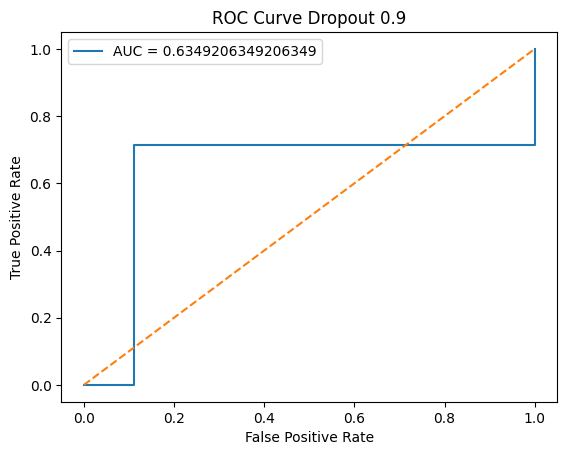

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 80)             │        32,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 2)              │            82 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,402 (138.29 KB)

 Trainable params: 35,402 (138.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 792ms/step - accuracy: 0.4500 - loss: 0.7681 - val_accuracy: 0.4783 - val_loss: 0.7102
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5500 - loss: 0.7627 - val_accuracy: 0.4783 - val_loss: 0.7101
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5500 - loss: 0.6606 - val_accuracy: 0.4783 - val_loss: 0.7100
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4500 - loss: 0.7402 - val_accuracy: 0.4783 - val_loss: 0.7100
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6500 - loss: 0.6858 - val_accuracy: 0.4783 - val_loss: 0.7099
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7500 - loss: 0.5773 - val_accuracy: 0.4783 - val_loss: 0.7099
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5000 - loss: 0.7661 - val_accuracy: 0.4783 - val_loss: 0.7099
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 0.8191 - val_accuracy: 0.4783 - val_loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
[[ 1  8]
 [ 4 10]]
0.4782608695652174


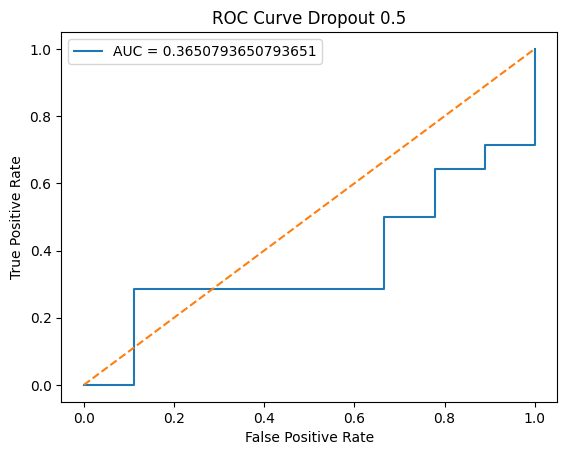

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 80)             │        32,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2)              │            82 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,402 (138.29 KB)

 Trainable params: 35,402 (138.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7000 - loss: 0.6568 - val_accuracy: 0.5217 - val_loss: 0.6954
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7000 - loss: 0.6934 - val_accuracy: 0.5217 - val_loss: 0.6953
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6000 - loss: 0.6925 - val_accuracy: 0.5217 - val_loss: 0.6953
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6000 - loss: 0.6854 - val_accuracy: 0.5217 - val_loss: 0.6952
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6000 - loss: 0.6764 - val_accuracy: 0.5217 - val_loss: 0.6951
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5500 - loss: 0.7043 - val_accuracy: 0.5217 - val_loss: 0.6950
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6000 - loss: 0.6828 - val_accuracy: 0.5217 - val_loss: 0.6949
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6000 - loss: 0.7047 - val_accuracy: 0.5217 - val_loss: 0.6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
[[5 4]
 [8 6]]
0.4782608695652174


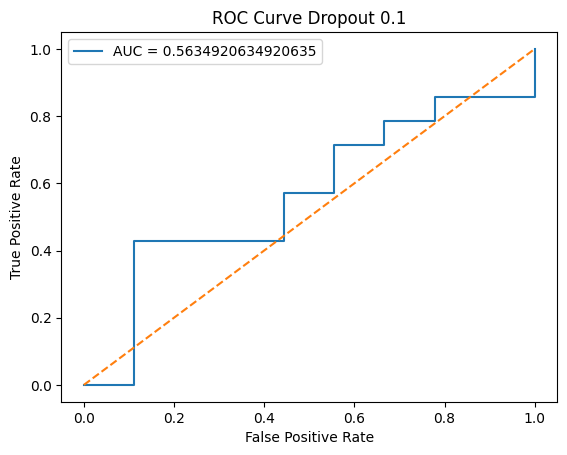

In [47]:
from tensorflow.keras.layers import Dropout
drop_values = [0.9, 0.5, 0.1]

for drop_rate in drop_values:
    model = Sequential()
    model.add(Flatten(input_shape=X_train.shape[1:]))
    model.add(Dense(80, activation="relu"))
    model.add(Dropout(drop_rate))
    model.add(Dense(40, activation="relu"))
    model.add(Dropout(drop_rate))
    model.add(Dense(2, activation="softmax"))

    model.compile(optimizer=SGD(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

    wandb.init(project="task4_dropout", name="dropout_" + str(drop_rate), reinit=True)

    model.summary()

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=10,
        validation_data=(X_test, y_test),
        callbacks=[WandbMetricsLogger()]
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print("Dropout:", drop_rate)
    print(test_loss)
    print(test_accuracy)

    test_preds = model.predict(X_test)
    y_pred = np.argmax(test_preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(confusion_matrix(y_true, y_pred))
    print(accuracy_score(y_true, y_pred))

    fpr, tpr, thresholds = roc_curve(y_true, test_preds[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Dropout " + str(drop_rate))
    plt.legend()
    plt.show()

    wandb.finish()

### Task 5. A Convolutional Neural Network

Finally, we are going to implement a convolutional neural network - a network type showing state-of-the-art results in learning from images. This time, your input will not be flattened but we will provide a 2D image as an input (20x20x1 pixels). Use the same hyperparameters as before, unless specified differenly.

#### Model definition

input -> conv1 -> pool1 -> conv2 -> dense1 -> dense2 -> softmax
* convolution layers: kernel size = 3x3, number of channels = 64, activation function = sigmoid
* max-pooling layers: kernel size = 2x2, strides = 2
* 1st dense layer: 50 neurons, activation function = sigmoid
* 2nd dense layer: 2 neurons, activation function = softmax
* optimizer = `sgd`
* use dropout (e.g. 0.2)

__Hint__: Use `.Flatten()` after before the dense layers to ensure a 1D vector as an input.

Like before, measure system's prerfomance and explain.

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 50)             │       156,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,520 (759.84 KB)

 Trainable params: 194,520 (759.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5500 - loss: 0.8276 - val_accuracy: 0.6087 - val_loss: 0.7299
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5500 - loss: 0.8743 - val_accuracy: 0.6087 - val_loss: 0.7287
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5500 - loss: 0.8173 - val_accuracy: 0.6087 - val_loss: 0.7276
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5500 - loss: 0.8195 - val_accuracy: 0.6087 - val_loss: 0.7265
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5500 - loss: 0.8945 - val_accuracy: 0.6087 - val_loss: 0.7252
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5500 - loss: 0.7758 - val_accuracy: 0.6087 - val_loss: 0.7240
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5500 - loss: 0.7421 - val_accuracy: 0.6087 - val_loss: 0.7229
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5500 - loss: 0.8076 - val_accuracy: 0.6087 - val_loss: 0.7217
E

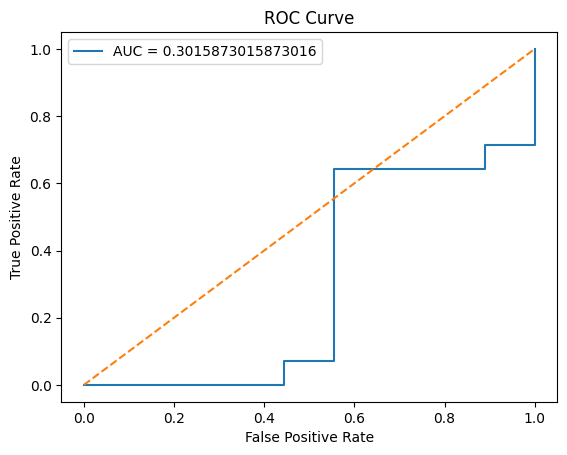

In [50]:
# Code for Part 2: Task 5
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D
model = Sequential()
model.add(Conv2D(64, (3, 3), activation="sigmoid", input_shape=(20, 20, 1)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Conv2D(64, (3, 3), activation="sigmoid"))
model.add(Flatten())
model.add(Dense(50, activation="sigmoid"))
model.add(Dropout(0.2))
model.add(Dense(2, activation="softmax"))

model.compile(optimizer=SGD(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

wandb.init(project="task5_cnn")

model.summary()

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=10,
    validation_data=(X_test, y_test),
    callbacks=[WandbMetricsLogger()]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(test_loss)
print(test_accuracy)

test_preds = model.predict(X_test)
y_pred = np.argmax(test_preds, axis=1)
y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred))
print(accuracy_score(y_true, y_pred))

fpr, tpr, thresholds = roc_curve(y_true, test_preds[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

wandb.finish()

### Task 6. A Deeper Convolutional Neural Network

#### Model definition

input -> conv1 -> pool1 -> conv2 -> conv3 -> fc1 -> fc2 -> softmax
* convolution layers: kernel size = 5x5, number of channels = 64, activation function = 'relu', padding = 'same'
* max-pooling layers: kernel size = 2x2, strides = 2
* 1st fully connected: 100 neurons, activation function = relu
* 2nd fully connected: 2 neurons, activation function = softmax
* optimizer = `sgd` (try also `adam`)
* use dropout (e.g. 0.5)

Like before, measure system's prerfomance and explain.

This was the last model you have trained. The `wandb` should now allow you to generate a common report for all train models (on the same graphs). Generate the report, download it as a `pdf`, and upload it in your assignment together with the notebook file.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 100)            │       640,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,894 (3.23 MB)

 Trainable params: 846,894 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.5500 - loss: 0.6874 - val_accuracy: 0.6522 - val_loss: 0.6857
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6000 - loss: 0.6858 - val_accuracy: 0.6522 - val_loss: 0.6857
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - loss: 0.6951 - val_accuracy: 0.6522 - val_loss: 0.6857
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2000 - loss: 0.6967 - val_accuracy: 0.6522 - val_loss: 0.6856
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 0.6522 - val_loss: 0.6856
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6000 - loss: 0.6887 - val_accuracy: 0.6522 - val_loss: 0.6856
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5000 - loss: 0.6961 - val_accuracy: 0.6522 - val_loss: 0.6856
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7000 - loss: 0.6879 - val_accuracy: 0.6522 - val_loss: 0.6855

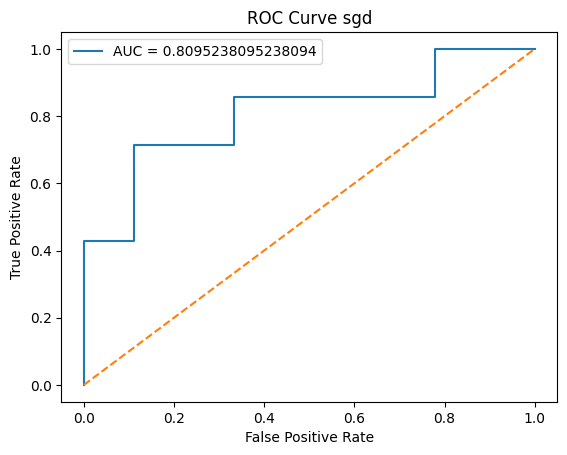

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │       640,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,894 (3.23 MB)

 Trainable params: 846,894 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5000 - loss: 0.6962 - val_accuracy: 0.5652 - val_loss: 0.6883
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5500 - loss: 0.6822 - val_accuracy: 0.6087 - val_loss: 0.6798
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7000 - loss: 0.6677 - val_accuracy: 0.6087 - val_loss: 0.6724
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5500 - loss: 0.6609 - val_accuracy: 0.6087 - val_loss: 0.6657
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5500 - loss: 0.6763 - val_accuracy: 0.6087 - val_loss: 0.6592
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5500 - loss: 0.6416 - val_accuracy: 0.6087 - val_loss: 0.6564
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6500 - loss: 0.6495 - val_accuracy: 0.6087 - val_loss: 0.6526
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6000 - loss: 0.6297 - val_accuracy: 0.6087 - val_loss: 0.64

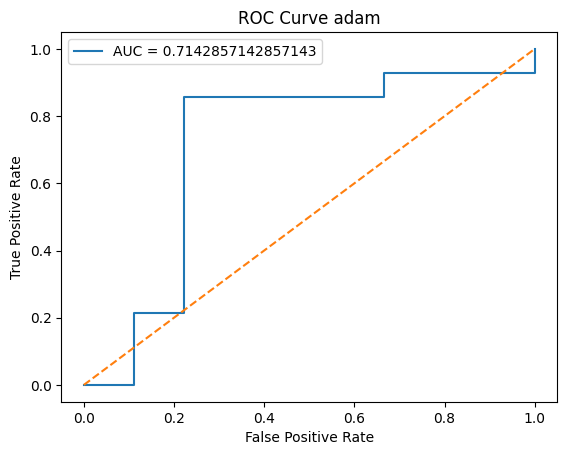

In [52]:
# Code for Part 2: Task 6
from tensorflow.keras.optimizers import Adam
optimizers = {
    "sgd": SGD(learning_rate=1e-4),
    "adam": Adam(learning_rate=1e-4)
}

for opt_name, opt in optimizers.items():
    model = Sequential()
    model.add(Conv2D(64, (5, 5), activation="relu", padding="same", input_shape=(20, 20, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(64, (5, 5), activation="relu", padding="same"))
    model.add(Conv2D(64, (5, 5), activation="relu", padding="same"))
    model.add(Flatten())
    model.add(Dense(100, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation="softmax"))

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

    wandb.init(project="task6_deeper_cnn", name=opt_name, reinit=True)

    model.summary()

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=10,
        validation_data=(X_test, y_test),
        callbacks=[WandbMetricsLogger()]
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(opt_name)
    print(test_loss)
    print(test_accuracy)

    test_preds = model.predict(X_test)
    y_pred = np.argmax(test_preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(confusion_matrix(y_true, y_pred))
    print(accuracy_score(y_true, y_pred))

    fpr, tpr, thresholds = roc_curve(y_true, test_preds[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve " + opt_name)
    plt.legend()
    plt.show()

    wandb.finish()